<a href="https://colab.research.google.com/github/mayurivedpathak01-alt/CodeVedX-Data-Science-Internship/blob/main/Credit_card_fraud_detection_csv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Path to dataset files: /kaggle/input/creditcardfraud


In [ ]:
import os
print(os.listdir(path))

['creditcard.csv']


In [ ]:
full_path = os.path.join(path, "creditcard.csv")
print(full_path)

/kaggle/input/creditcardfraud/creditcard.csv


In [ ]:
DATA_PATH = full_path

In [ ]:
DATA_PATH = os.path.join(path, "creditcard.csv")

In [ ]:
import os
DATA_PATH = os.path.join(path, "creditcard.csv")
main()

Loading data from /kaggle/input/creditcardfraud/creditcard.csv ...
Shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727% (highly imbalanced)

Train shape: (227845, 30), Test shape: (56962, 30)

Applying SMOTE oversampling...
After SMOTE: {0: 227451, 1: 227451}

Training Logistic Regression...
Training Random Forest...


KeyboardInterrupt: 

In [ ]:
def train_models(X_train, y_train, used_resampling):
    class_weight = None if used_resampling else "balanced"

    print("\nTraining Logistic Regression...")
    log_reg = LogisticRegression(
        max_iter=1000, class_weight=class_weight, random_state=RANDOM_STATE
    )
    log_reg.fit(X_train, y_train)

    print("Training Random Forest (faster settings)...")
    rf = RandomForestClassifier(
        n_estimators=50,      # down from 200
        max_depth=10,         # down from 12
        n_jobs=-1,            # use all CPU cores
        class_weight=class_weight,
        random_state=RANDOM_STATE,
    )
    rf.fit(X_train, y_train)

    return {"Logistic Regression": log_reg, "Random Forest": rf}

In [ ]:
DATA_PATH = os.path.join(path, "creditcard.csv")
main()

Loading data from /kaggle/input/creditcardfraud/creditcard.csv ...
Shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727% (highly imbalanced)

Train shape: (227845, 30), Test shape: (56962, 30)

Applying SMOTE oversampling...
After SMOTE: {0: 227451, 1: 227451}

Training Logistic Regression...
Training Random Forest (faster settings)...

EVALUATION (fraud = positive class)

--- Logistic Regression ---
Precision: 0.0581
Recall:    0.9184
F1-score:  0.1094
ROC-AUC:   0.9698

Confusion Matrix (rows=actual, cols=predicted):
[[55406  1458]
 [    8    90]]

Full report:
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


--- Random Forest ---
Precision: 0.4221


In [ ]:
# Rerun pipeline, but keep intermediate variables in memory this time
df = load_data(DATA_PATH)
X, y = preprocess(df)
X_train, X_test, y_train, y_test = split_data(X, y)
X_train_bal, y_train_bal = handle_imbalance(X_train, y_train, method="smote")
models = train_models(X_train_bal, y_train_bal, used_resampling=True)
evaluate(models, X_test, y_test)

rf_model = models["Random Forest"]

Loading data from /kaggle/input/creditcardfraud/creditcard.csv ...
Shape: (284807, 31)
Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64
Fraud rate: 0.1727% (highly imbalanced)

Train shape: (227845, 30), Test shape: (56962, 30)

Applying SMOTE oversampling...
After SMOTE: {0: 227451, 1: 227451}

Training Logistic Regression...
Training Random Forest (faster settings)...

EVALUATION (fraud = positive class)

--- Logistic Regression ---
Precision: 0.0581
Recall:    0.9184
F1-score:  0.1094
ROC-AUC:   0.9698

Confusion Matrix (rows=actual, cols=predicted):
[[55406  1458]
 [    8    90]]

Full report:
              precision    recall  f1-score   support

     Genuine       1.00      0.97      0.99     56864
       Fraud       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962


--- Random Forest ---
Precision: 0.4221


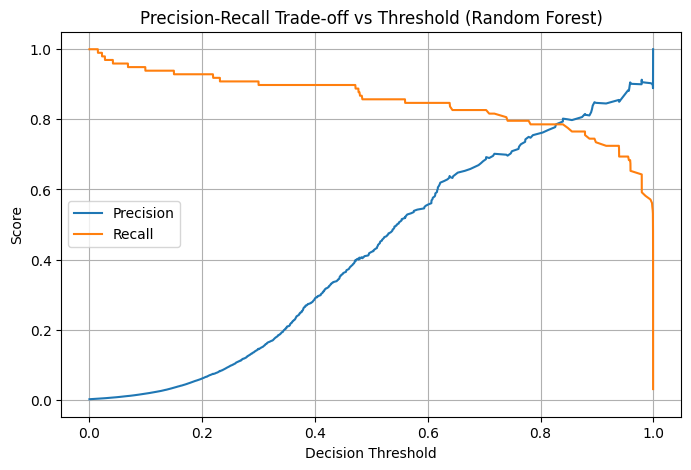

Threshold=0.3: Precision=0.144, Recall=0.898, F1=0.249
Threshold=0.5: Precision=0.422, Recall=0.857, F1=0.566
Threshold=0.7: Precision=0.686, Recall=0.827, F1=0.750
Threshold=0.9: Precision=0.845, Recall=0.724, F1=0.780


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

probs = rf_model.predict_proba(X_test)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(8, 5))
plt.plot(thresholds, precisions[:-1], label="Precision")
plt.plot(thresholds, recalls[:-1], label="Recall")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Precision-Recall Trade-off vs Threshold (Random Forest)")
plt.legend()
plt.grid(True)
plt.show()

for t in [0.3, 0.5, 0.7, 0.9]:
    preds_t = (probs >= t).astype(int)
    p = precision_score(y_test, preds_t)
    r = recall_score(y_test, preds_t)
    f1 = f1_score(y_test, preds_t)
    print(f"Threshold={t}: Precision={p:.3f}, Recall={r:.3f}, F1={f1:.3f}")

Top 10 most important features for fraud detection:
V14    0.243391
V4     0.125342
V10    0.121700
V17    0.083901
V12    0.075291
V11    0.067546
V3     0.056131
V16    0.042025
V7     0.030598
V2     0.024191
dtype: float64


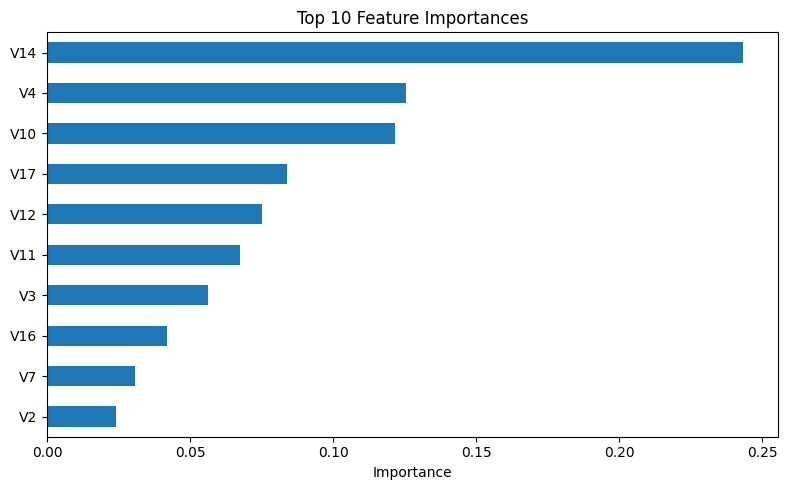

In [ ]:
import pandas as pd

importances = pd.Series(rf_model.feature_importances_, index=X_train.columns)
top_features = importances.sort_values(ascending=False).head(10)

print("Top 10 most important features for fraud detection:")
print(top_features)

top_features.plot(kind='barh', figsize=(8, 5), title="Top 10 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
def predict_transaction(rf_model, feature_columns, threshold=0.5, **kwargs):
    row = {col: 0.0 for col in feature_columns}
    for key, value in kwargs.items():
        if key not in row:
            raise ValueError(f"Unknown feature '{key}'. Available: {feature_columns}")
        row[key] = value
    X_new = pd.DataFrame([row])[feature_columns]
    prob = rf_model.predict_proba(X_new)[0][1]
    prediction = "FRAUD" if prob >= threshold else "GENUINE"
    print(f"Fraud probability: {prob:.4f}")
    print(f"Prediction (threshold={threshold}): {prediction}")
    return prediction, prob

In [ ]:
predict_transaction(
    rf_model,
    feature_columns=list(X_train.columns),
    V14=-8.5,
    V4=6.2,
    V10=-7.1,
    Amount_scaled=0.3,
    threshold=0.5,
)

Fraud probability: 0.5331
Prediction (threshold=0.5): FRAUD


('FRAUD', np.float64(0.5331270172867609))

In this task I built a model that can find fraud transactions in credit card data. The main problem I faced was that fraud cases are very less compared to normal transactions, only 0.17% of the total data, so if I just check accuracy the model can cheat by saying every transaction is genuine and still get 99.8% accuracy. Because of this I used precision, recall and F1-score to actually check how well the model is finding fraud.
I trained two models, Logistic Regression and Random Forest. Logistic Regression was able to catch 92% of the fraud cases but it also gave too many wrong alerts, around 1458 genuine transactions were marked as fraud which is not good for real use. Random Forest gave better result overall, it caught 86% of fraud with much less wrong alerts, and its ROC-AUC score was 0.98 which means it is doing a good job separating fraud from genuine transactions.
Since the data was imbalanced, I used SMOTE technique to create more fraud samples for training so the model can learn the fraud pattern properly. After training I also checked the feature importance and found that V14 was the most useful feature, it alone contributed almost 24% in the model decision, followed by V4 and V10.
From this task I learned that accuracy is not always a good measure, especially when the data is imbalanced like this one. It is more important to check precision and recall together. Random Forest worked better than Logistic Regression for this problem, and if we tune the threshold value properly it can be even more useful for real world fraud detection systems like banks use.